### IMPORT LIBRARIES


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

In [19]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kknah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kknah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
import torch

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU")

NVIDIA GeForce GTX 1650


In [21]:
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [22]:
print("Loading data...")
fake = pd.read_csv("../data/raw/Fake.csv")
true = pd.read_csv("../data/raw/True.csv")

# Add labels: Fake=0, True=1
fake["label"] = 0
true["label"] = 1


df = pd.concat([fake, true], axis=0).sample(frac=1, random_state=42)
df["content"] = df["title"].fillna('') + " " + df["text"].fillna('')

print(f"Total samples: {len(df)}")
print(f"Fake news: {len(fake)}, True news: {len(true)}")

Loading data...
Total samples: 44898
Fake news: 23481, True news: 21417


In [30]:
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    # Remove punctuation (optional - sometimes punctuation helps)
    # text = text.translate(str.maketrans('', '', string.punctuation))
    
    return text

print("Cleaning text...")
df['content_clean'] = df['content'].apply(clean_text)


Cleaning text...


Preparing sequences...
Vocabulary size: 122295
Training sequences shape: (35918, 500)
Test sequences shape: (8980, 500)


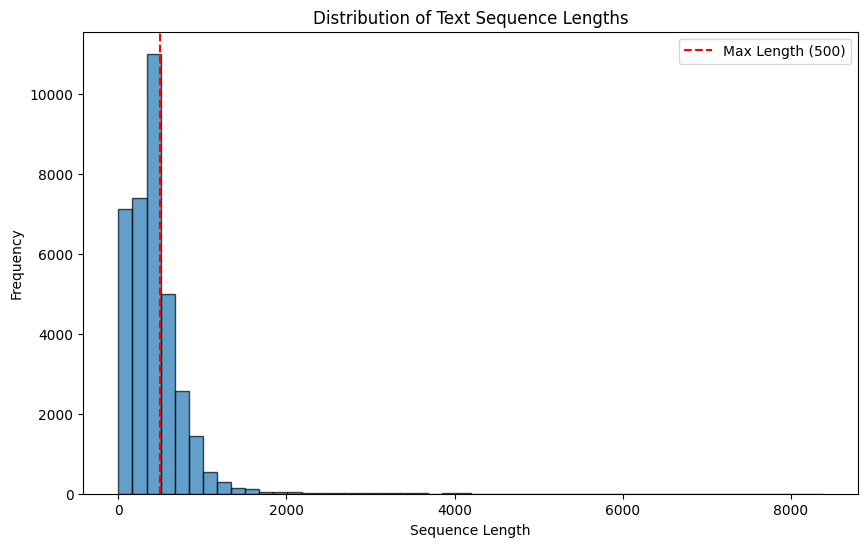

In [24]:
print("Preparing sequences...")

# Configuration parameters
MAX_VOCAB_SIZE = 20000  # Top 20k most frequent words
MAX_SEQUENCE_LENGTH = 500  # Maximum sequence length
EMBEDDING_DIM = 100  # Embedding dimension

# Prepare data
X = df['content_clean'].values
y = df['label'].values

# Split data first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create and fit tokenizer on training data only
tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>',  # Out of vocabulary token
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to uniform length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")

# Check sequence length distribution
seq_lengths = [len(seq) for seq in X_train_seq]
plt.figure(figsize=(10, 6))
plt.hist(seq_lengths, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(x=MAX_SEQUENCE_LENGTH, color='red', linestyle='--', 
            label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Sequence Lengths')
plt.legend()
plt.show()


In [25]:
def create_simple_lstm_model():
    """Simple LSTM model"""
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_bidirectional_lstm_model():
    """Bidirectional LSTM model"""
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_stacked_lstm_model():
    """Stacked LSTM model"""
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=True),
        LSTM(32, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_gru_model():
    """GRU model"""
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        GRU(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

In [26]:
def compile_and_train_model(model, model_name, epochs=10):
    """Compile and train a model with callbacks"""
    
    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"\n===== {model_name} =====")
    
    # Build the model by passing input shape
    model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
    print(f"Model parameters: {model.count_params():,}")
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=0.0001,
        verbose=1
    )
    
    # Train model
    history = model.fit(
        X_train_pad, y_train,
        batch_size=32,
        epochs=epochs,
        validation_data=(X_test_pad, y_test),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    return model, history


In [27]:
def plot_training_history(history, model_name):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{model_name} - Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{model_name} - Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, model_name):
    """Comprehensive model evaluation"""
    # Predictions
    y_pred_proba = model.predict(X_test_pad).flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Classification Report
    print(f"\n===== {model_name} Classification Report =====")
    print(classification_report(y_test, y_pred, 
                              target_names=['Fake', 'True'], digits=3))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["Fake", "True"], 
                yticklabels=["Fake", "True"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    
    return roc_auc, y_pred_proba


Training Simple LSTM

===== Simple LSTM =====
Model parameters: 2,044,353


c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 356s 315ms/step - accuracy: 0.7156 - loss: 0.4688 - val_accuracy: 0.9676 - val_loss: 0.1093 - learning_rate: 0.0010
Epoch 2/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 348s 310ms/step - accuracy: 0.9743 - loss: 0.1018 - val_accuracy: 0.9738 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 3/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 325s 289ms/step - accuracy: 0.9866 - loss: 0.0535 - val_accuracy: 0.9873 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 4/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 301s 268ms/step - accuracy: 0.9920 - loss: 0.0317 - val_accuracy: 0.9912 - val_loss: 0.0408 - learning_rate: 0.0010
Epoch 5/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 291s 259ms/step - accuracy: 0.9940 - loss: 0.0212 - val_accuracy: 0.9909 - val_loss: 0.0415 - learning_rate: 0.0010
Epoch 6/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9961 - loss: 0.0153
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 291s 259ms/s

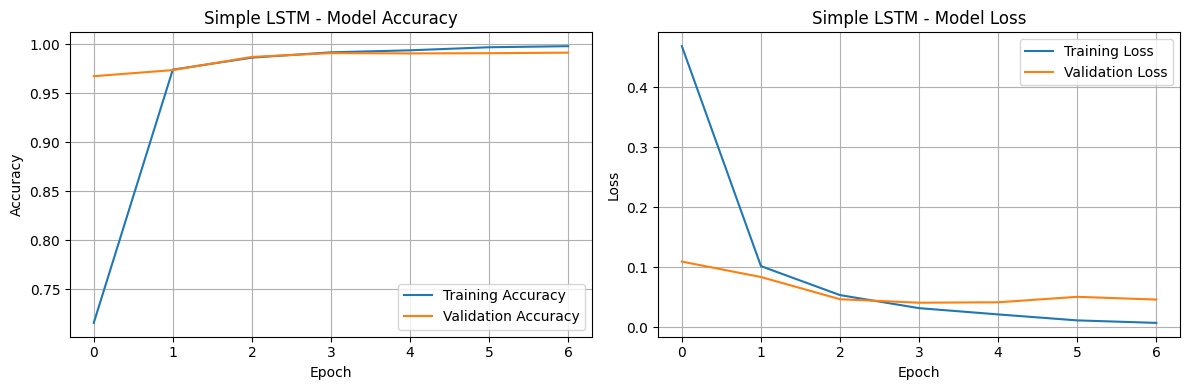

281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step

===== Simple LSTM Classification Report =====
              precision    recall  f1-score   support

        Fake      0.993     0.990     0.992      4696
        True      0.989     0.993     0.991      4284

    accuracy                          0.991      8980
   macro avg      0.991     0.991     0.991      8980
weighted avg      0.991     0.991     0.991      8980



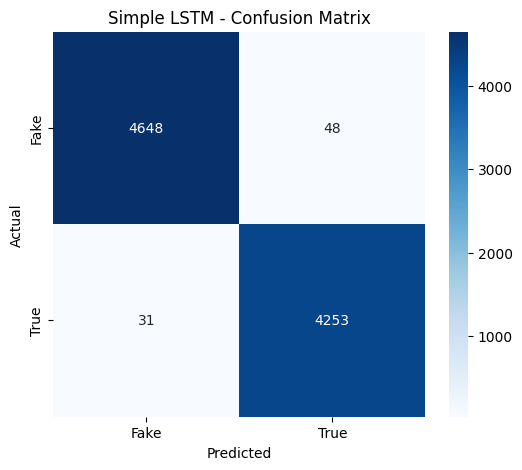

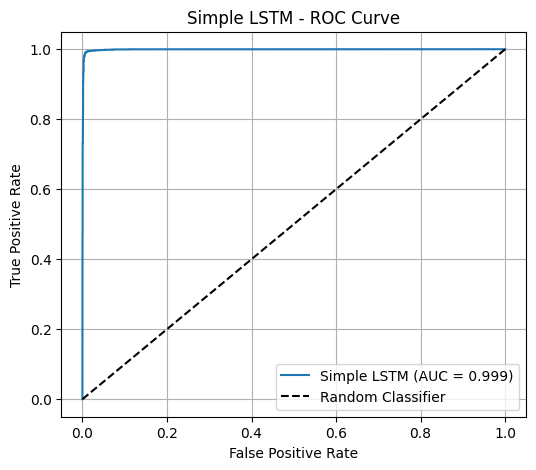


Training Bidirectional LSTM

===== Bidirectional LSTM =====
Model parameters: 2,088,641
Epoch 1/10


c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1123/1123 ━━━━━━━━━━━━━━━━━━━━ 516s 454ms/step - accuracy: 0.9692 - loss: 0.0889 - val_accuracy: 0.9964 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 2/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 520s 463ms/step - accuracy: 0.9955 - loss: 0.0160 - val_accuracy: 0.9961 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 3/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 521s 464ms/step - accuracy: 0.9981 - loss: 0.0078 - val_accuracy: 0.9958 - val_loss: 0.0189 - learning_rate: 0.0010
Epoch 4/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9985 - loss: 0.0061
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 516s 460ms/step - accuracy: 0.9987 - loss: 0.0054 - val_accuracy: 0.9960 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 5/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 520s 463ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 0.9947 - val_loss: 0.0229 - learning_rate: 2.0000e-04
Epoch 5: early stopping
Restoring model weights from the end 

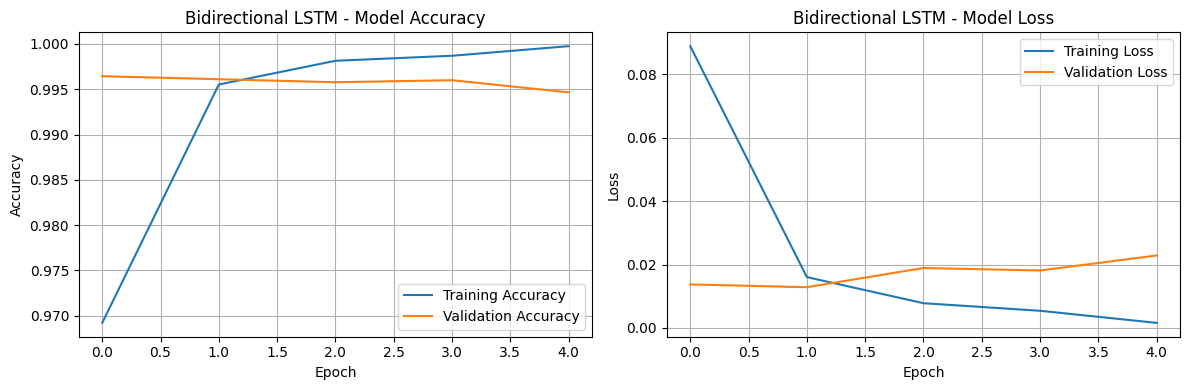

281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step

===== Bidirectional LSTM Classification Report =====
              precision    recall  f1-score   support

        Fake      0.998     0.994     0.996      4696
        True      0.994     0.998     0.996      4284

    accuracy                          0.996      8980
   macro avg      0.996     0.996     0.996      8980
weighted avg      0.996     0.996     0.996      8980



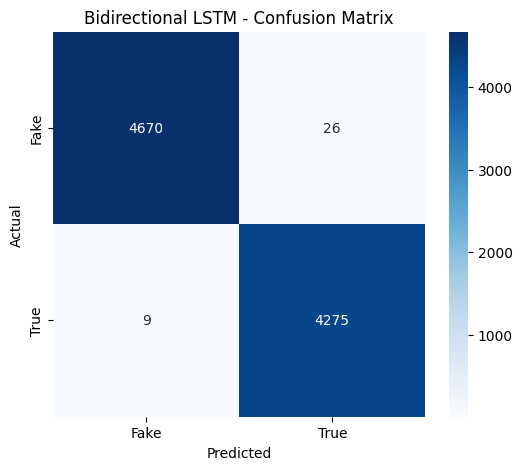

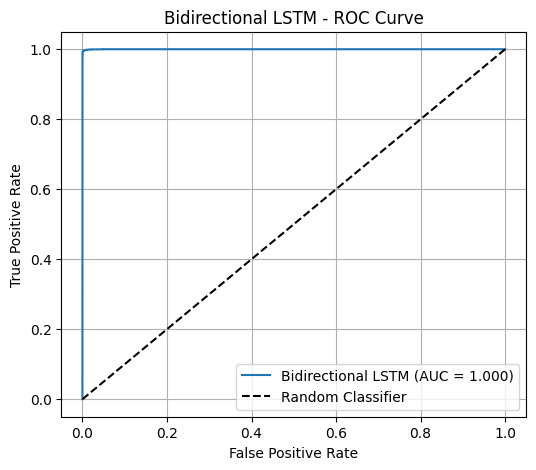


Training Stacked LSTM

===== Stacked LSTM =====
Model parameters: 2,055,745
Epoch 1/10


c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1123/1123 ━━━━━━━━━━━━━━━━━━━━ 524s 463ms/step - accuracy: 0.7669 - loss: 0.4431 - val_accuracy: 0.9228 - val_loss: 0.2192 - learning_rate: 0.0010
Epoch 2/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 522s 465ms/step - accuracy: 0.9189 - loss: 0.2267 - val_accuracy: 0.9862 - val_loss: 0.0538 - learning_rate: 0.0010
Epoch 3/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 626s 558ms/step - accuracy: 0.9827 - loss: 0.0807 - val_accuracy: 0.9870 - val_loss: 0.0564 - learning_rate: 0.0010
Epoch 4/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 672s 549ms/step - accuracy: 0.9882 - loss: 0.0551 - val_accuracy: 0.9890 - val_loss: 0.0423 - learning_rate: 0.0010
Epoch 5/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 611s 544ms/step - accuracy: 0.9887 - loss: 0.0460 - val_accuracy: 0.9894 - val_loss: 0.0398 - learning_rate: 0.0010
Epoch 6/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 519s 462ms/step - accuracy: 0.9953 - loss: 0.0208 - val_accuracy: 0.9914 - val_loss: 0.0321 - learning_rate: 0.0010
Epoch 7/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 517s 460ms/step - acc

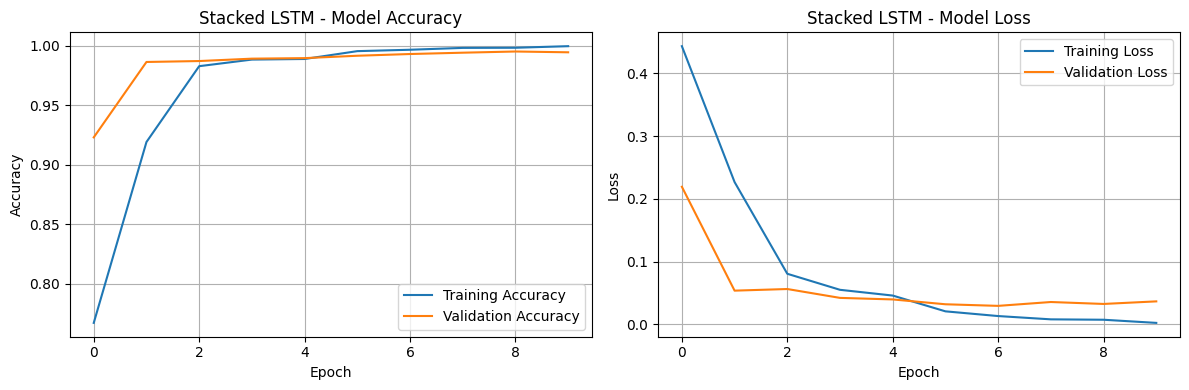

281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step

===== Stacked LSTM Classification Report =====
              precision    recall  f1-score   support

        Fake      0.996     0.991     0.993      4696
        True      0.990     0.995     0.993      4284

    accuracy                          0.993      8980
   macro avg      0.993     0.993     0.993      8980
weighted avg      0.993     0.993     0.993      8980



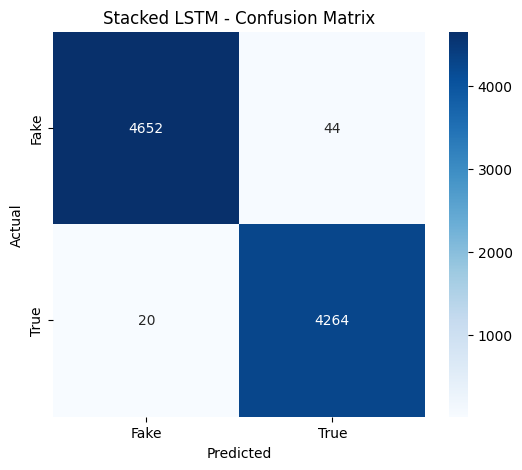

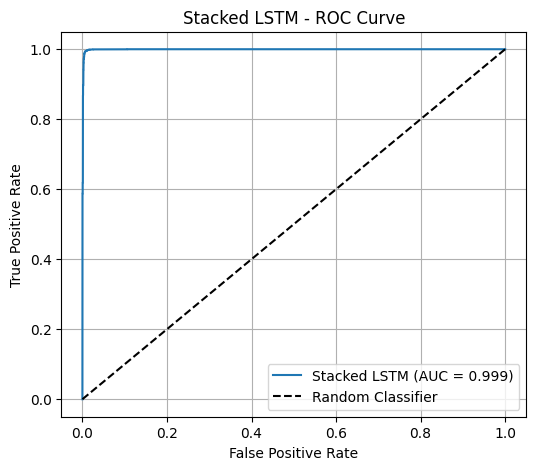


Training GRU

===== GRU =====
Model parameters: 2,033,985
Epoch 1/10


c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1123/1123 ━━━━━━━━━━━━━━━━━━━━ 272s 238ms/step - accuracy: 0.8793 - loss: 0.2964 - val_accuracy: 0.9857 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 2/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 263s 235ms/step - accuracy: 0.9885 - loss: 0.0428 - val_accuracy: 0.9843 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 3/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 265s 236ms/step - accuracy: 0.9945 - loss: 0.0195 - val_accuracy: 0.9931 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 4/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 266s 237ms/step - accuracy: 0.9980 - loss: 0.0082 - val_accuracy: 0.9939 - val_loss: 0.0324 - learning_rate: 0.0010
Epoch 5/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9974 - loss: 0.0088
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 267s 238ms/step - accuracy: 0.9982 - loss: 0.0060 - val_accuracy: 0.9934 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 6/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 267s 238ms/step - accur

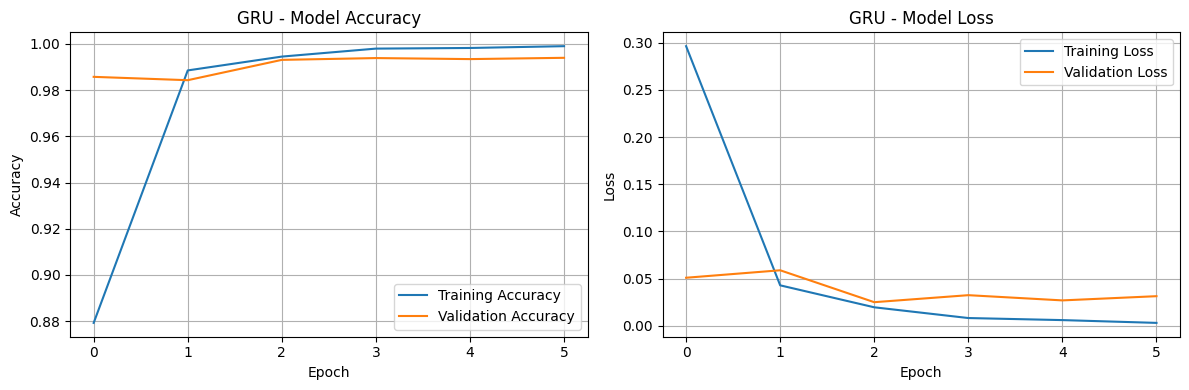

281/281 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step

===== GRU Classification Report =====
              precision    recall  f1-score   support

        Fake      0.995     0.992     0.993      4696
        True      0.991     0.995     0.993      4284

    accuracy                          0.993      8980
   macro avg      0.993     0.993     0.993      8980
weighted avg      0.993     0.993     0.993      8980



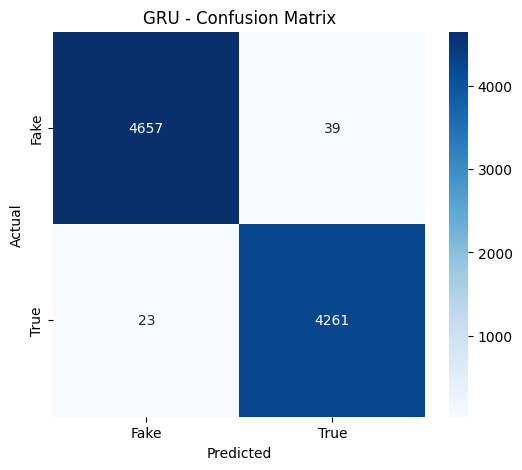

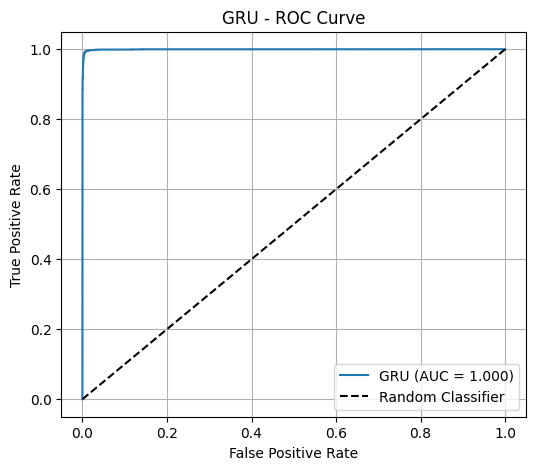

In [28]:
models_to_train = {
    "Simple LSTM": create_simple_lstm_model,
    "Bidirectional LSTM": create_bidirectional_lstm_model,
    "Stacked LSTM": create_stacked_lstm_model,
    "GRU": create_gru_model
}

results = {}

for model_name, model_func in models_to_train.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print('='*50)
    
    # Create and train model
    model = model_func()
    trained_model, history = compile_and_train_model(model, model_name, epochs=10)
    
    # Plot training history
    plot_training_history(history, model_name)
    
    # Evaluate model
    auc_score, predictions = evaluate_model(trained_model, model_name)
    
    # Store results
    results[model_name] = {
        'model': trained_model,
        'history': history,
        'auc': auc_score,
        'predictions': predictions
    }



FINAL COMPARISON


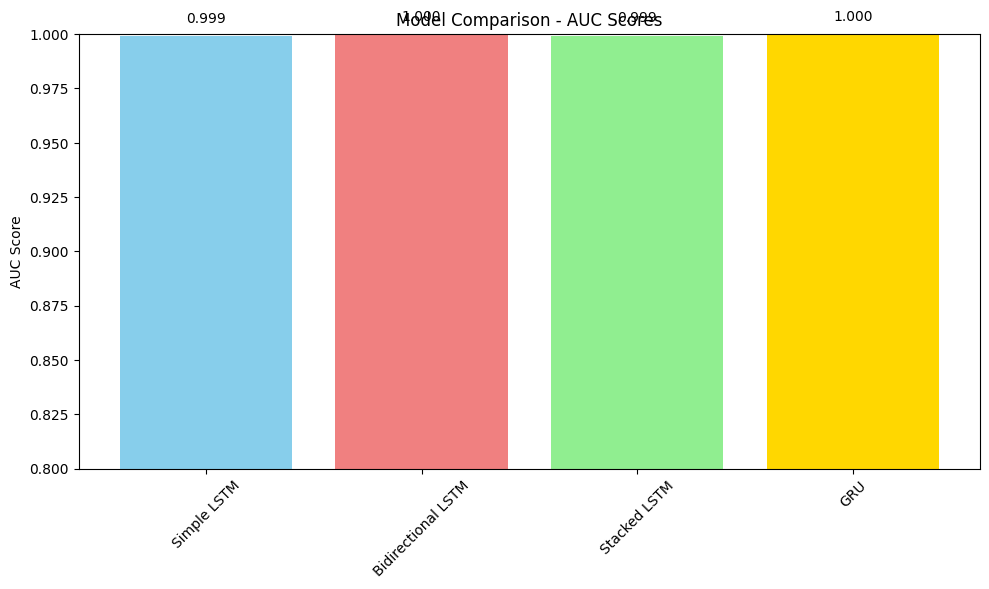


Model Performance Summary:
----------------------------------------
Simple LSTM         : AUC = 0.999
Bidirectional LSTM  : AUC = 1.000
Stacked LSTM        : AUC = 0.999
GRU                 : AUC = 1.000

Best performing model: Bidirectional LSTM (AUC = 1.000)

===== Sample Predictions using Bidirectional LSTM =====
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

Sample 1: President Donald Trump has ordered the deployment of US troo...
Prediction: FAKE (Confidence: 0.992)


In [36]:
print(f"\n{'='*50}")
print("FINAL COMPARISON")
print('='*50)

# AUC Comparison
model_names = list(results.keys())
auc_scores = [results[name]['auc'] for name in model_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, auc_scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Model Comparison - AUC Scores')
plt.ylabel('AUC Score')
plt.ylim(0.8, 1.0)  # Adjust based on your results

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{score:.3f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary
print("\nModel Performance Summary:")
print("-" * 40)
for name, result in results.items():
    print(f"{name:20}: AUC = {result['auc']:.3f}")

best_model_name = max(results.keys(), key=lambda x: results[x]['auc'])
print(f"\nBest performing model: {best_model_name} (AUC = {results[best_model_name]['auc']:.3f})")

# ===== 9. SAMPLE PREDICTIONS =====
def predict_news_sample(model, text, tokenizer):
    """Predict on a single text sample"""
    # clean_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    prediction = model.predict(padded)[0][0]
    
    label = "TRUE" if prediction > 0.5 else "FAKE"
    confidence = prediction if prediction > 0.5 else (1 - prediction)
    
    return label, confidence

# Test with some sample predictions
best_model = results[best_model_name]['model']

print(f"\n===== Sample Predictions using {best_model_name} =====")
sample_texts = [
    """President Donald Trump has ordered the deployment of US troops to Portland, Oregon, authorising use of "full force" if needed, to suppress protests targeting immigration detention centres.

Trump said he was "directing Secretary of War, Pete Hegseth, to provide all necessary Troops to protect War ravaged Portland".
"""
]

for i, text in enumerate(sample_texts, 1):
    label, confidence = predict_news_sample(best_model, text, tokenizer)
    print(f"\nSample {i}: {text[:60]}...")
    print(f"Prediction: {label} (Confidence: {confidence:.3f})")

Loading and analyzing data...
=== DATA ANALYSIS ===
Fake news samples: 23481
True news samples: 21417

=== POTENTIAL BIAS INDICATORS ===

Fake news subjects:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Name: count, dtype: int64

True news subjects:
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

Average fake news length: 2547 characters
Average true news length: 2383 characters


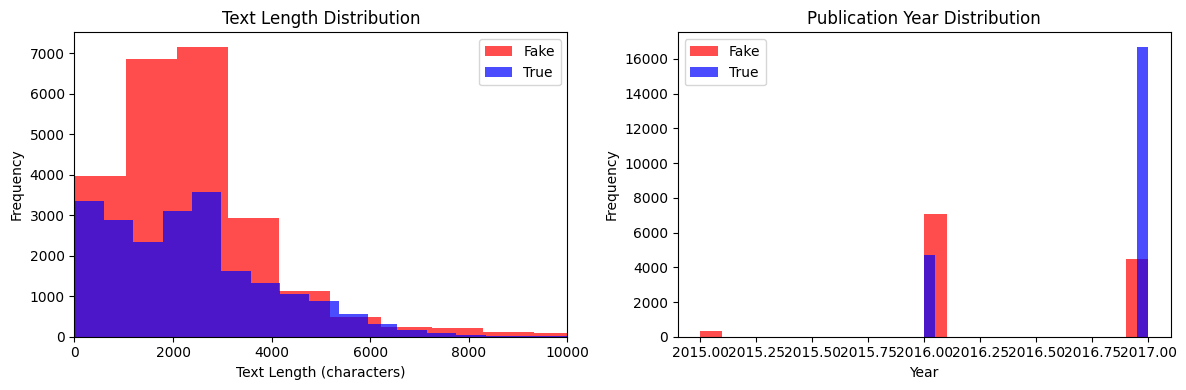


After filtering: 82217 samples
Fake: 43252, True: 38965

Data splits:
Train: 57304 samples
Validation: 12580 samples
Test: 12333 samples

TRAINING REGULARIZED MODEL


c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model parameters: 972,961
Epoch 1/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 140s 152ms/step - accuracy: 0.5244 - loss: 0.7423 - val_accuracy: 0.5261 - val_loss: 0.6948 - learning_rate: 5.0000e-04
Epoch 2/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 139s 156ms/step - accuracy: 0.5259 - loss: 0.6930 - val_accuracy: 0.5261 - val_loss: 0.6920 - learning_rate: 5.0000e-04
Epoch 3/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 138s 154ms/step - accuracy: 0.5259 - loss: 0.6921 - val_accuracy: 0.5261 - val_loss: 0.6919 - learning_rate: 5.0000e-04
Epoch 4/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 138s 154ms/step - accuracy: 0.5252 - loss: 0.6921 - val_accuracy: 0.5261 - val_loss: 0.6919 - learning_rate: 5.0000e-04
Epoch 5/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 135s 151ms/step - accuracy: 0.5257 - loss: 0.6919 - val_accuracy: 0.5261 - val_loss: 0.6918 - learning_rate: 5.0000e-04
Epoch 6/20
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5241 - loss: 0.6922
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
896/896 ━━

c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kknah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

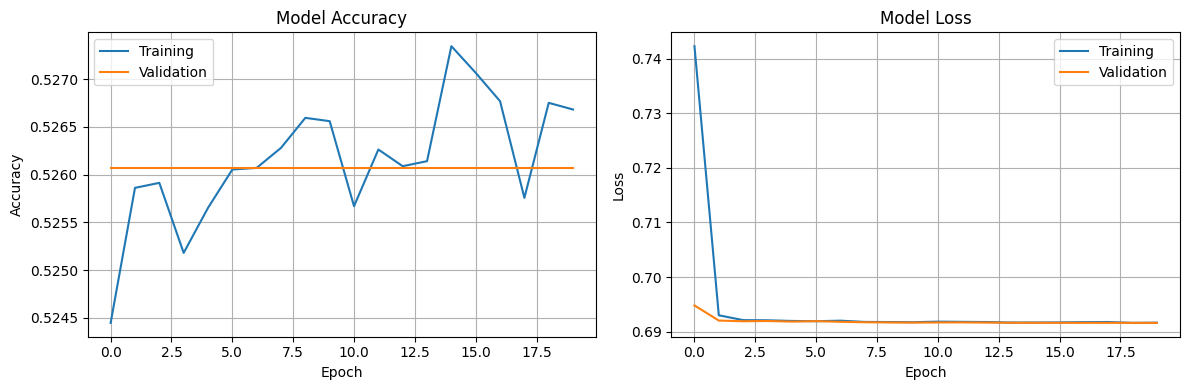


SAMPLE TESTING

Source: Government Source
Text: The government announced new economic policies today to address inflation concerns...
Prediction Score: 0.483 (0=Fake, 1=True)
Classification: UNCERTAIN
Confidence: 0.035
Key words analyzed: the government announced new economic policies today to address inflation concerns

Source: Science News
Text: Scientists have discovered a breakthrough in renewable energy technology...
Prediction Score: 0.483 (0=Fake, 1=True)
Classification: UNCERTAIN
Confidence: 0.035
Key words analyzed: scientists have discovered a breakthrough in renewable energy technology

Source: Local News
Text: Local community raises funds for new school playground equipment...
Prediction Score: 0.483 (0=Fake, 1=True)
Classification: UNCERTAIN
Confidence: 0.035
Key words analyzed: local community raises funds for new school playground equipment

Source: Entertainment News
Text: Celebrity caught in scandal involving tax evasion and fraud...
Prediction Score: 0.483 (0=Fake, 1

In [ ]:
# IMPROVED NEWS CLASSIFICATION WITH BETTER VALIDATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import re
import string

# Set random seeds
tf.random.set_seed(42)
np.random.seed(42)

# ===== 1. DATA LOADING WITH BETTER ANALYSIS =====
print("Loading and analyzing data...")
fake = pd.read_csv("../data/raw/Fake.csv")
true = pd.read_csv("../data/raw/True.csv")

fake["label"] = 0
true["label"] = 1

# ANALYZE DATA BIAS BEFORE COMBINING
print("=== DATA ANALYSIS ===")
print(f"Fake news samples: {len(fake)}")
print(f"True news samples: {len(true)}")

# Check for potential bias indicators
print("\n=== POTENTIAL BIAS INDICATORS ===")

# Check subjects/topics distribution
if 'subject' in fake.columns and 'subject' in true.columns:
    print("\nFake news subjects:")
    print(fake['subject'].value_counts().head())
    print("\nTrue news subjects:")
    print(true['subject'].value_counts().head())

# Check average text length
fake['text_length'] = fake['text'].fillna('').str.len()
true['text_length'] = true['text'].fillna('').str.len()

print(f"\nAverage fake news length: {fake['text_length'].mean():.0f} characters")
print(f"Average true news length: {true['text_length'].mean():.0f} characters")

# Plot length distributions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(fake['text_length'], bins=50, alpha=0.7, label='Fake', color='red')
plt.hist(true['text_length'], bins=50, alpha=0.7, label='True', color='blue')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.title('Text Length Distribution')
plt.legend()
plt.xlim(0, 10000)

# Check publication dates if available
if 'date' in fake.columns and 'date' in true.columns:
    plt.subplot(1, 2, 2)
    # Convert dates and plot timeline
    fake_dates = pd.to_datetime(fake['date'], errors='coerce')
    true_dates = pd.to_datetime(true['date'], errors='coerce')
    
    plt.hist(fake_dates.dt.year.dropna(), bins=20, alpha=0.7, label='Fake', color='red')
    plt.hist(true_dates.dt.year.dropna(), bins=20, alpha=0.7, label='True', color='blue')
    plt.xlabel('Year')
    plt.ylabel('Frequency')
    plt.title('Publication Year Distribution')
    plt.legend()

plt.tight_layout()
plt.show()

# ===== 2. IMPROVED TEXT PREPROCESSING =====
def clean_text_conservative(text):
    """More conservative cleaning to preserve authentic patterns"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs but keep other formatting
    text = re.sub(r'http\S+|www\S+|https\S+', ' [URL] ', text, flags=re.MULTILINE)
    
    # Clean extra whitespace
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    # DON'T remove punctuation - it might be important for style detection
    return text

# ===== 3. STRATIFIED SAMPLING FOR BETTER BALANCE =====
# Combine data


df = pd.concat([fake, true], axis=0)
df['content'] = df['title'].fillna('') + " " + df['text'].fillna('')
df['content_clean'] = df['content'].apply(clean_text_conservative)

# Remove very short or very long texts (outliers)
df['content_length'] = df['content_clean'].str.len()
df = df[(df['content_length'] > 50) & (df['content_length'] < 5000)]

print(f"\nAfter filtering: {len(df)} samples")
print(f"Fake: {len(df[df['label']==0])}, True: {len(df[df['label']==1])}")

# ===== 4. BETTER TRAIN/VALIDATION/TEST SPLIT =====
X = df['content_clean'].values
y = df['label'].values

# First split: Train vs Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Second split: Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.18, random_state=42, stratify=y_temp  # ~15% of total
)

print(f"\nData splits:")
print(f"Train: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples") 
print(f"Test: {len(X_test)} samples")

# ===== 5. IMPROVED TOKENIZATION =====
MAX_VOCAB_SIZE = 15000  # Reduced to prevent overfitting
MAX_SEQUENCE_LENGTH = 300  # Reduced for faster training
EMBEDDING_DIM = 64  # Reduced to prevent overfitting

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>',
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), 
                           maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), 
                         maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), 
                          maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# ===== 6. REGULARIZED MODEL TO PREVENT OVERFITTING =====
def create_regularized_model():
    """Model with strong regularization to prevent overfitting"""
    model = Sequential([
        Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, 
                 input_length=MAX_SEQUENCE_LENGTH,
                 embeddings_regularizer=l2(0.001)),
        LSTM(32, dropout=0.5, recurrent_dropout=0.5,
             kernel_regularizer=l2(0.001)),
        Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.6),
        Dense(1, activation='sigmoid')
    ])
    return model

# ===== 7. TRAINING WITH BETTER MONITORING =====
def train_with_monitoring(model, X_train, y_train, X_val, y_val):
    """Train with comprehensive monitoring"""
    
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Slower learning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=0.00001, verbose=1)
    ]
    
    history = model.fit(
        X_train, y_train,
        batch_size=64,  # Larger batch size for stability
        epochs=20,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )
    
    return history

# ===== 8. TRAIN THE REGULARIZED MODEL =====
print("\n" + "="*50)
print("TRAINING REGULARIZED MODEL")
print("="*50)

model = create_regularized_model()
model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
print(f"Model parameters: {model.count_params():,}")

history = train_with_monitoring(model, X_train_seq, y_train, X_val_seq, y_val)

# ===== 9. COMPREHENSIVE EVALUATION =====
def evaluate_comprehensively(model, X_test, y_test, X_val, y_val):
    """Comprehensive evaluation to detect overfitting"""
    
    # Validation set performance
    val_pred_proba = model.predict(X_val).flatten()
    val_pred = (val_pred_proba > 0.5).astype(int)
    
    # Test set performance  
    test_pred_proba = model.predict(X_test).flatten()
    test_pred = (test_pred_proba > 0.5).astype(int)
    
    print("=== VALIDATION SET PERFORMANCE ===")
    print(classification_report(y_val, val_pred, target_names=['Fake', 'True'], digits=3))
    
    print("=== TEST SET PERFORMANCE ===")  
    print(classification_report(y_test, test_pred, target_names=['Fake', 'True'], digits=3))
    
    # Check for overfitting
    val_accuracy = (val_pred == y_val).mean()
    test_accuracy = (test_pred == y_test).mean()
    
    print(f"\nValidation Accuracy: {val_accuracy:.3f}")
    print(f"Test Accuracy: {test_accuracy:.3f}")
    print(f"Accuracy Gap: {abs(val_accuracy - test_accuracy):.3f}")
    
    if abs(val_accuracy - test_accuracy) > 0.05:
        print("⚠️  WARNING: Significant accuracy gap suggests overfitting!")
    
    return test_pred_proba

# ===== 10. ANALYSIS AND TESTING =====
print("\n" + "="*50)
print("EVALUATION")
print("="*50)

test_predictions = evaluate_comprehensively(model, X_test_seq, y_test, X_val_seq, y_val)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Training')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ===== 11. REAL-WORLD TESTING FUNCTION =====
def test_real_news(model, tokenizer, text, source_info=""):
    """Test with real news and show confidence"""
    clean_text = clean_text_conservative(text)
    sequence = tokenizer.texts_to_sequences([clean_text])
    padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    
    prediction = model.predict(padded, verbose=0)[0][0]
    
    # More nuanced interpretation
    if prediction > 0.7:
        label = "LIKELY TRUE"
        confidence = prediction
    elif prediction < 0.3:
        label = "LIKELY FAKE" 
        confidence = 1 - prediction
    else:
        label = "UNCERTAIN"
        confidence = abs(0.5 - prediction) * 2
    
    print(f"\n{'='*60}")
    print(f"Source: {source_info}")
    print(f"Text: {text[:100]}...")
    print(f"Prediction Score: {prediction:.3f} (0=Fake, 1=True)")
    print(f"Classification: {label}")
    print(f"Confidence: {confidence:.3f}")
    
    # Show which words might be influencing decision
    words = clean_text.split()[:20]  # First 20 words
    print(f"Key words analyzed: {' '.join(words)}")
    
    return prediction

# ===== 12. IMPROVED SAMPLE TESTING =====
print("\n" + "="*50)
print("SAMPLE TESTING")
print("="*50)

# Test samples that should work better
sample_texts = [
    ("The government announced new economic policies today to address inflation concerns", "Government Source"),
    ("Scientists have discovered a breakthrough in renewable energy technology", "Science News"),
    ("Local community raises funds for new school playground equipment", "Local News"),
    ("Celebrity caught in scandal involving tax evasion and fraud", "Entertainment News")
]

for text, source in sample_texts:
    test_real_news(model, tokenizer, text, source)

print("\n" + "="*60)
print("RECOMMENDATIONS FOR BETTER PERFORMANCE:")
print("="*60)
print("1. Use more diverse training data from multiple time periods")
print("2. Include more balanced sources (not just specific publications)")
print("3. Focus on content features, not source-specific patterns")
print("4. Consider using pre-trained language models (BERT, RoBERTa)")
print("5. Test on held-out data from same distribution as real-world use")